In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import operator
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from util.api import get_versions_df, get_update_count_df, get_update_count_df_2, get_count_updated_packages_by_lts, get_lts_list

%matplotlib inline
plt.style.use('classic')

/home/giacamole/projects/memoria-haskell/stackage-evolution/notebooks/answers/util/api.py:560: SyntaxWarning: invalid escape sequence '\d'
  range1 = re.match("(.*?)(\d.*)", ranges[0]).groups()
/home/giacamole/projects/memoria-haskell/stackage-evolution/notebooks/answers/util/api.py:564: SyntaxWarning: invalid escape sequence '\d'
  range2 = re.match("(.*?)(\d.*)", ranges[1]).groups()


In [2]:
lts_list = get_lts_list()
df_list = []
df_by_category_list = []

for idx, lts in enumerate(lts_list):
    df = pd.read_pickle(f'../../data/dfs/lts-{lts}/lts-{lts}.df')
    df_list.append(df)

# Research Questions (RQs)

- **RQ 1.** What packages are the most used? Which of them are outside from the Stackage selection?
- **RQ 2.** How many dependencies of packages are outside from the Stackage selection (in)directly?
- **RQ 3.** How frequently are the packages updated? 

Regarding monads, we analyze the evolution of dependencies of monad modules available in the mtl package:

- **RQ 4.** How has the use of monads evolved?
- **RQ 5.** Are there packages that stopped using monads?

## RQ 3. How frequently are the packages updated? 

Construimos un nuevo DafaFrame que nos muestra la version de cada paquete en cada LTS que llamamos `versions_df`. Procesamos este DataFrame contando la cantidad de veces en que cada paquete actualizo su version a lo largo del tiempo. Luego, calculamos el porcentaje de paquetes que actualizo su version en cada LTS respecto a la cantidad de paquetes totales en el snapshot anterior.

- La primera version tiene alrededor de 800 paquetes y el porcentaje de actualizacion depende de la version anterior
- Al inicio de las versiones se actualizaron una gran cantidad de paquetes entre cada snapshot (2-22, 3-22 y 6-35), sin embargo el periodo de tiempo (+6 meses) existente entre estas versiones es superior, ya que no existia regularidad en la publicacion de versiones
- Durante las versiones 12-14, 12-26, 13-11 y 13-19 se ve una disminucion en la cantidad de paquetes actualziados sin emargo el margen de tiempo (1-3 meses) entre estas versiones es bastante menor a las otras publicacinoes.
- En promedio se actializan el 28% de los paquetes y la desviacion estandar X

In [3]:
versions_df = get_versions_df(df_list)

In [10]:
#update_count_df = get_update_count_df(df_list, versions_df)
update_count_df = get_update_count_df_2(df_list, versions_df)

In [5]:
count_lts_pkg, count_updated_packages_by_lts = get_count_updated_packages_by_lts(df_list, update_count_df)

In [6]:
pkg_unupdated = [len(df_list[idx])-count_lts_pkg[lts_list[idx+1]] for idx in range(len(df_list)-1)]
stats.f_oneway(list(count_lts_pkg.values()),list(pkg_unupdated))

F_onewayResult(statistic=np.float64(304.6168151861264), pvalue=np.float64(8.106783479287943e-27))

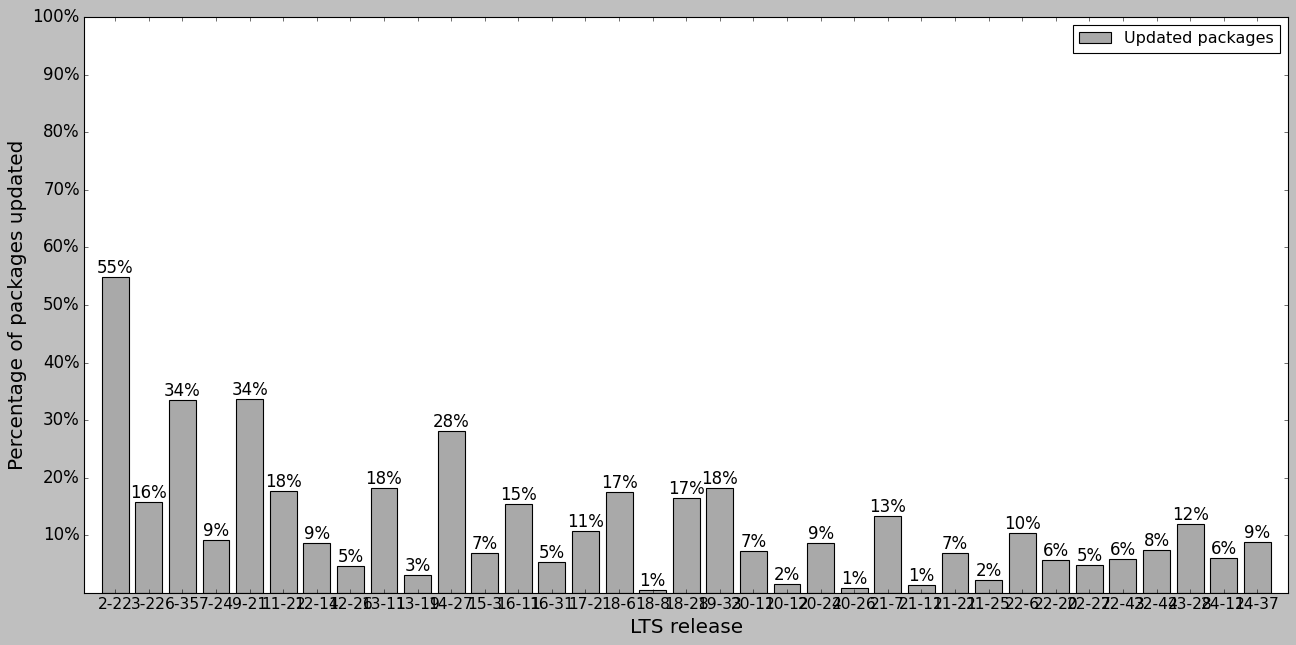

In [7]:
index = list(count_updated_packages_by_lts.keys())
updated_packages = list(count_updated_packages_by_lts.values())
fig, ax = plt.subplots(figsize=(14,8))
ax.margins(0.015) 
plt.subplots_adjust(bottom=0.1, right=1.2, top=1)

bar1 = ax.bar(index, updated_packages, width=0.8, color='darkgrey', align='center', label='Updated packages')
ax.bar_label(bar1, labels=list(map(lambda per: f"{round(per)}%", updated_packages)),fontsize=15)

ax.legend(loc='best')
ax.set_xlabel('LTS release',fontsize=18)
ax.set_ylabel('Percentage of packages updated',fontsize=18)
ax.set_xticks(lts_list[1:])
ax.set_xticklabels(lts_list[1:],fontsize=14)
ax.set_yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_yticklabels(['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%'],fontsize=15)
plt.savefig("../../graphs/rq3.pdf", format='pdf', bbox_inches='tight')
plt.show()

Column sums (total updates per LTS):
0-7        0
2-22     453
3-22     380
6-35     720
7-24     294
9-21     971
11-22    978
12-14    494
12-26    154
13-11    482
13-19    124
14-27    742
15-3     306
16-11    484
16-31    232
17-2     297
18-6     618
18-8      26
18-28    470
19-33    703
20-11    397
20-12     59
20-24    281
20-26     42
21-7     421
21-11     61
21-21    230
21-25     87
22-6     324
22-20    254
22-27    208
22-43    231
22-44    319
23-28    444
24-11    307
24-37    366
dtype: int64

Any non-zero values?
0-7      False
2-22      True
3-22      True
6-35      True
7-24      True
9-21      True
11-22     True
12-14     True
12-26     True
13-11     True
13-19     True
14-27     True
15-3      True
16-11     True
16-31     True
17-2      True
18-6      True
18-8      True
18-28     True
19-33     True
20-11     True
20-12     True
20-24     True
20-26     True
21-7      True
21-11     True
21-21     True
21-25     True
22-6      True
22-20     True
22-27     

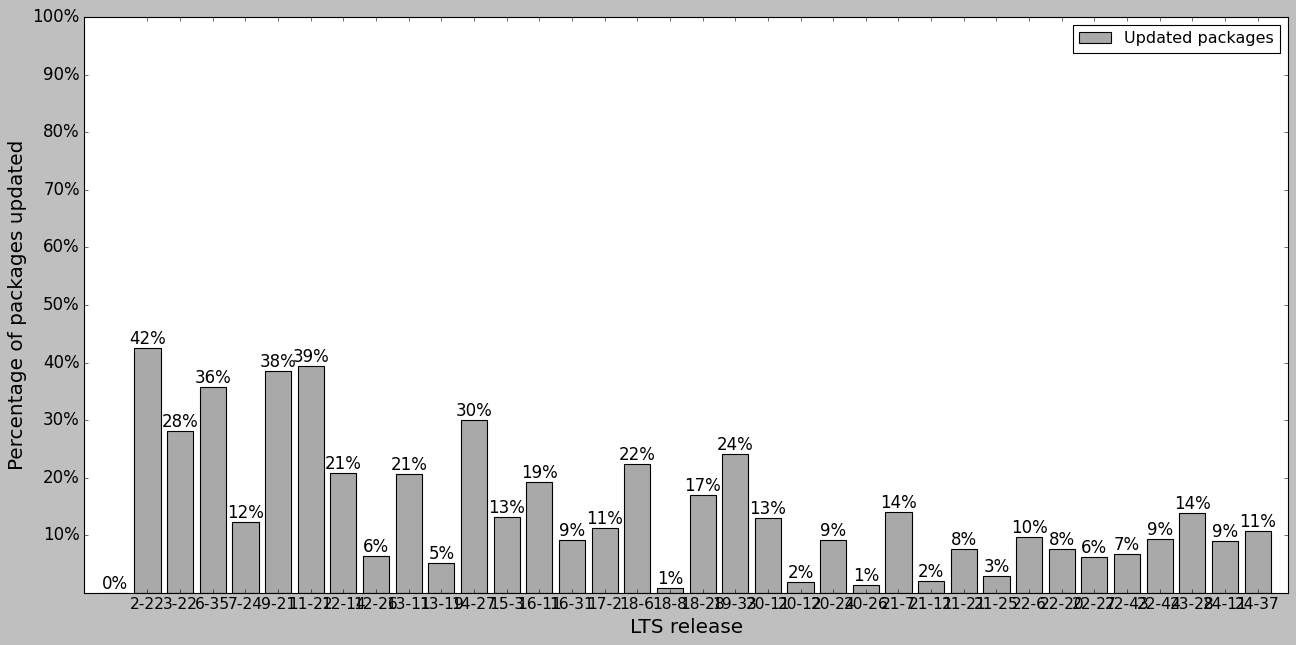

In [11]:
##  made  with ai for debugging ##
# Create a fresh update_count_df with zeros
update_count_df = pd.DataFrame(0, index=versions_df.index, columns=lts_list)

# Fill in the update counts
for pkg in update_count_df.index:
    for i in range(1, len(lts_list)):  # Start from 1 to compare with previous
        curr_lts = lts_list[i]
        prev_lts = lts_list[i-1]
        
        curr_version = versions_df.loc[pkg, curr_lts]
        prev_version = versions_df.loc[pkg, prev_lts]
        
        # Check if version exists and changed
        if curr_version != "" and prev_version != "" and curr_version != prev_version:
            update_count_df.loc[pkg, curr_lts] = 1

# Verify it worked
print("Column sums (total updates per LTS):")
print(update_count_df.sum())
print("\nAny non-zero values?")
print((update_count_df > 0).any())
print("\nSample of non-zero values:")
print(update_count_df[update_count_df > 0].head(10))

# Calculate percentages for each LTS (starting from second one)
count_updated_packages_by_lts = {}
count_lts_pkg = {}

for idx, lts in enumerate(lts_list):
    total_packages = len(df_list[idx])
    count_lts_pkg[lts] = total_packages
    
    if idx == 0:
        count_updated_packages_by_lts[lts] = 0  # First LTS has 0% updates
    else:
        updated = update_count_df[lts].sum()
        percentage = (updated / total_packages) * 100 if total_packages > 0 else 0
        count_updated_packages_by_lts[lts] = percentage

print("Update percentages by LTS:")
for lts, pct in count_updated_packages_by_lts.items():
    print(f"  {lts}: {pct:.2f}%")

index = list(count_updated_packages_by_lts.keys())
updated_packages = list(count_updated_packages_by_lts.values())

fig, ax = plt.subplots(figsize=(14,8))
ax.margins(0.015) 
plt.subplots_adjust(bottom=0.1, right=1.2, top=1)

bar1 = ax.bar(index, updated_packages, width=0.8, color='darkgrey', align='center', label='Updated packages')
ax.bar_label(bar1, labels=list(map(lambda per: f"{round(per)}%", updated_packages)), fontsize=15)

ax.legend(loc='best')
ax.set_xlabel('LTS release', fontsize=18)
ax.set_ylabel('Percentage of packages updated', fontsize=18)
ax.set_xticks(lts_list[1:])  # Skip first LTS for labels
ax.set_xticklabels(lts_list[1:], fontsize=14)
ax.set_yticks([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_yticklabels(['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%'], fontsize=15)
plt.savefig("../../graphs/rq3.pdf", format='pdf', bbox_inches='tight')
plt.show()